# Retail Intelligence Business Analytics

## Notebook 4: Sales & Profit Performance Analysis

### Objective

The objective of this notebook is to perform exploratory data analysis on the cleaned Global Superstore dataset, identify key business trends, evaluate sales and profitability, and generate insights that support strategic business decision-making and Power BI dashboard development.  

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# Chart Style
plt.style.use("ggplot")

# Load cleaned dataset
df = pd.read_csv("../data/processed/cleaned_orders.csv")

# Convert dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

## 1. Overall Business Performance

Begin by evaluating the overall sales, profit, and order volume to establish a baseline understanding of business performance before exploring detailed trends.

In [2]:
kpis = {
    "Total Sales": df["Sales"].sum(),
    "Total Profit": df["Profit"].sum(),
    "Total Orders": df["Order ID"].nunique(),
    "Total Customers": df["Customer ID"].nunique(),
    "Average Order Value": df["Sales"].mean()
}

pd.DataFrame(kpis.items(), columns=["Metric","Value"])

,Metric,Value
0,Total Sales,1.264250e+07
1,Total Profit,1.467457e+06
2,Total Orders,2.572800e+04
3,Total Customers,1.741500e+04
4,Average Order Value,2.464906e+02


In [3]:
summary = pd.DataFrame({
    "Sales":[df["Sales"].sum()],
    "Profit":[df["Profit"].sum()],
    "Orders":[df["Order ID"].nunique()],
    "Customers":[df["Customer ID"].nunique()]
})

summary

,Sales,Profit,Orders,Customers
0,1.264250e+07,1.467457e+06,25728,17415


### Observations

- The business generated strong overall sales.
- Profitability remains positive.
- The customer base is well distributed across multiple markets.

## 2. Monthly Sales Trend

Analyze monthly sales patterns to identify seasonality, growth trends, and fluctuations in business performance over time.

In [4]:
monthly_sales = (
    df
    .groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

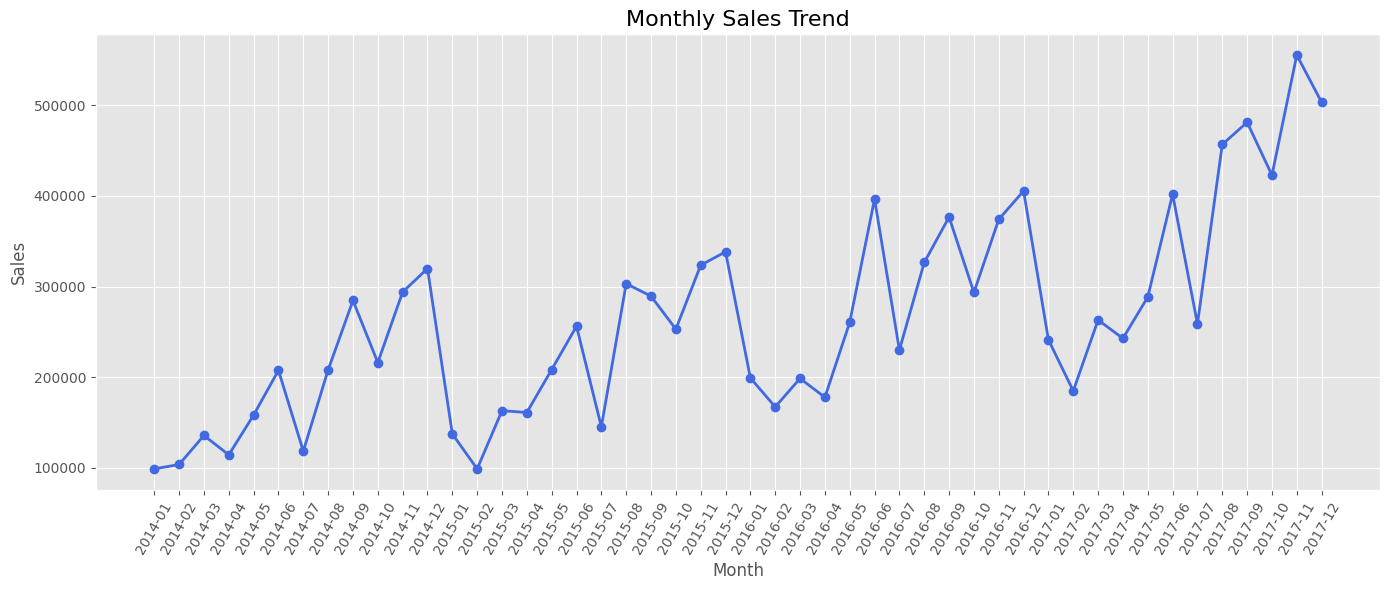

In [5]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2,
    color="royalblue"
)

plt.xticks(rotation=60)

plt.title("Monthly Sales Trend", fontsize=16)

plt.xlabel("Month")

plt.ylabel("Sales")

plt.tight_layout()

plt.show()

### Observations

- Sales fluctuate throughout the year.
- Certain months show noticeably higher revenue.
- These peaks may indicate seasonal demand.

## 3. Monthly Profit Trend

Compare monthly profitability with sales performance to understand whether increased sales consistently translate into higher profits.

In [6]:
monthly_profit = (
    df
    .groupby(df["Order Date"].dt.to_period("M"))["Profit"]
    .sum()
)

monthly_profit.index = monthly_profit.index.astype(str)

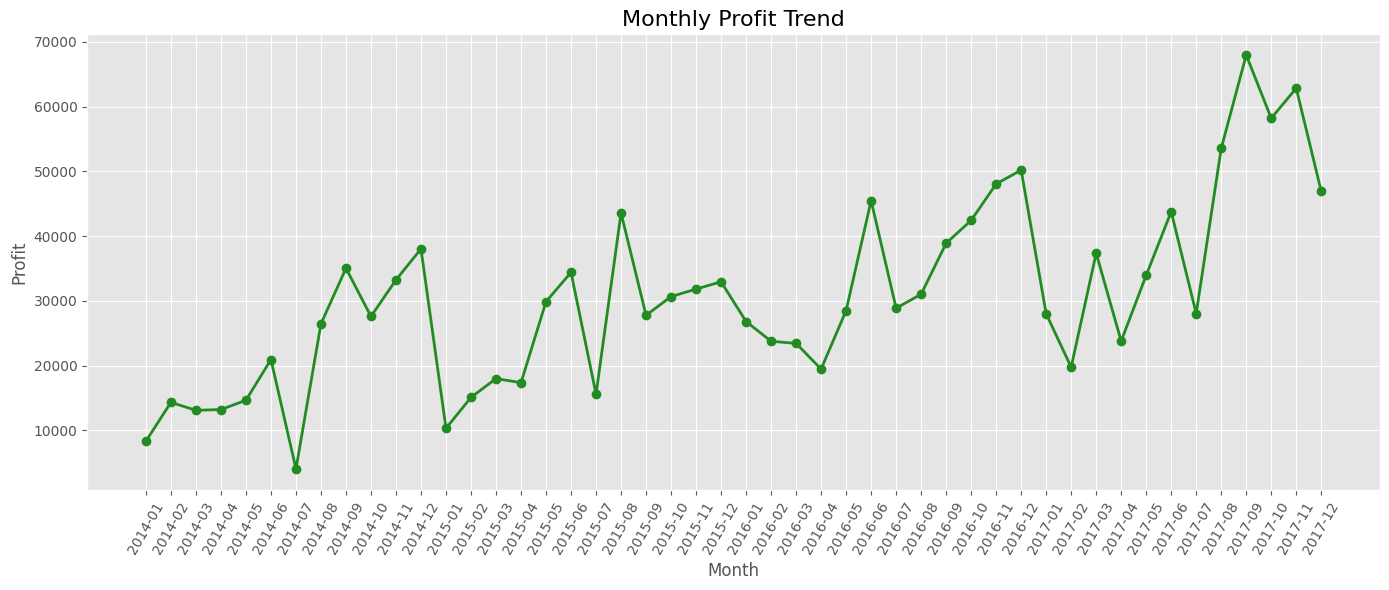

In [7]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_profit.index,
    monthly_profit.values,
    marker="o",
    linewidth=2,
    color="forestgreen"
)

plt.xticks(rotation=60)

plt.title("Monthly Profit Trend", fontsize=16)

plt.xlabel("Month")

plt.ylabel("Profit")

plt.tight_layout()

plt.show()

### Observations

- Profit does not always follow sales.
- Some months generate high revenue but relatively low profit.

## 4. Category Performance

Evaluate the contribution of each product category to total sales and profit to identify high-performing and underperforming business segments.

In [8]:
category_sales = (
    df.groupby("Category")[["Sales","Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

category_sales

,Sales,Profit
Category,,
Technology,4.744557e+06,663778.73318
Furniture,4.110452e+06,285082.73020
Office Supplies,3.787493e+06,518595.82790


C:\Users\Swaransh Mishra\AppData\Local\Temp\ipykernel_27636\2195382539.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


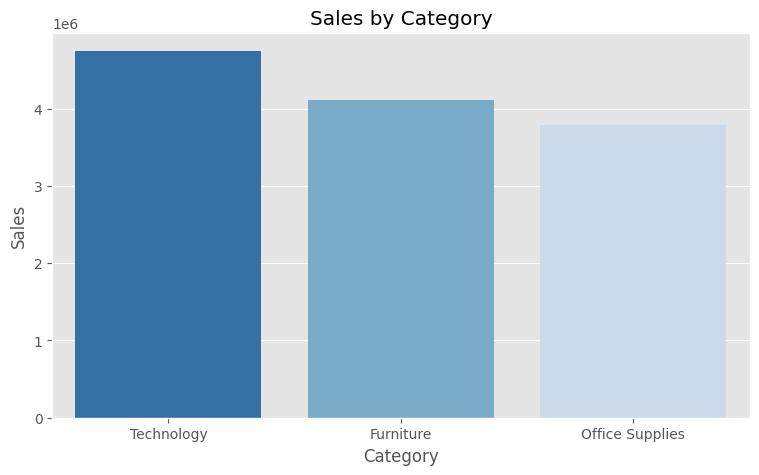

In [9]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=category_sales.reset_index(),
    x="Category",
    y="Sales",
    palette="Blues_r"
)

plt.title("Sales by Category")

plt.show()

C:\Users\Swaransh Mishra\AppData\Local\Temp\ipykernel_27636\1891624468.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


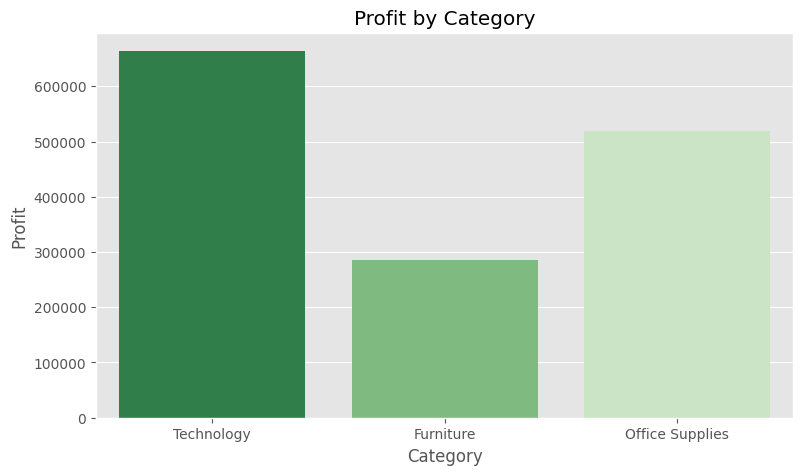

In [10]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=category_sales.reset_index(),
    x="Category",
    y="Profit",
    palette="Greens_r"
)

plt.title("Profit by Category")

plt.show()

### Observations

- Technology and Furniture contribute significantly to revenue.
- Profitability varies across categories.

## 5. Top Performing Sub-Categories

Identify the highest-performing product sub-categories based on sales and profitability to support product-level business decisions.

In [11]:
top_products = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Sub-Category
Phones         1.706824e+06
Copiers        1.509436e+06
Chairs         1.501682e+06
Bookcases      1.466572e+06
Storage        1.126813e+06
Appliances     1.010536e+06
Machines       7.790601e+05
Tables         7.570419e+05
Accessories    7.492370e+05
Binders        4.618694e+05
Name: Sales, dtype: float64

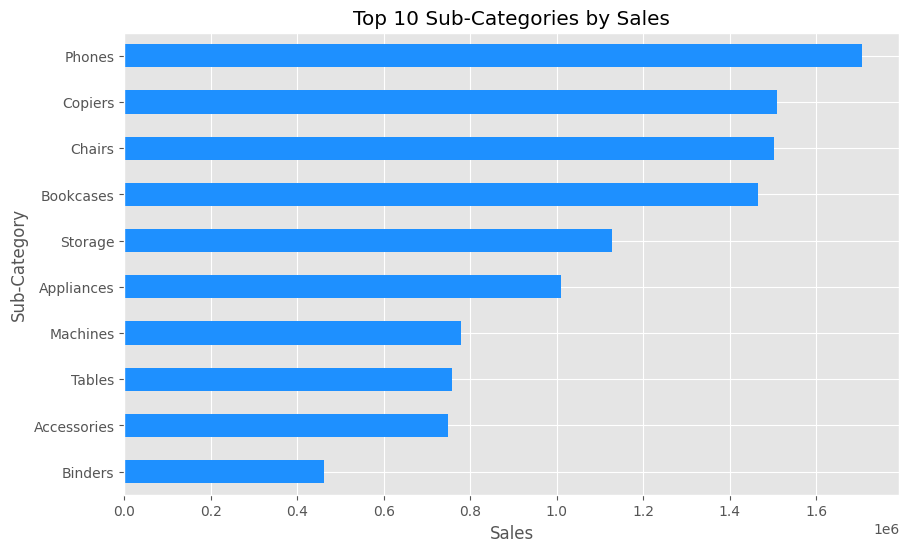

In [12]:
plt.figure(figsize=(10,6))

top_products.sort_values().plot(
    kind="barh",
    color="dodgerblue"
)

plt.title("Top 10 Sub-Categories by Sales")

plt.xlabel("Sales")

plt.show()

## 6. Regional Performance

Compare business performance across geographic regions to identify areas of strong growth and regions requiring operational improvements.

In [13]:
region = (
    df.groupby("Region")[["Sales","Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

region

,Sales,Profit
Region,,
Western Europe,1.731930e+06,218433.50850
Central America,1.223101e+06,158981.64816
Oceania,1.100185e+06,120089.11200
Southeastern Asia,8.844232e+05,17852.32900
Southern Asia,8.665727e+05,159336.42700
Eastern Asia,8.550594e+05,167101.85100
Western US,7.254578e+05,108418.44890
Eastern US,6.787812e+05,91522.78000
Northern Europe,6.367792e+05,83923.91700


C:\Users\Swaransh Mishra\AppData\Local\Temp\ipykernel_27636\3977704053.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


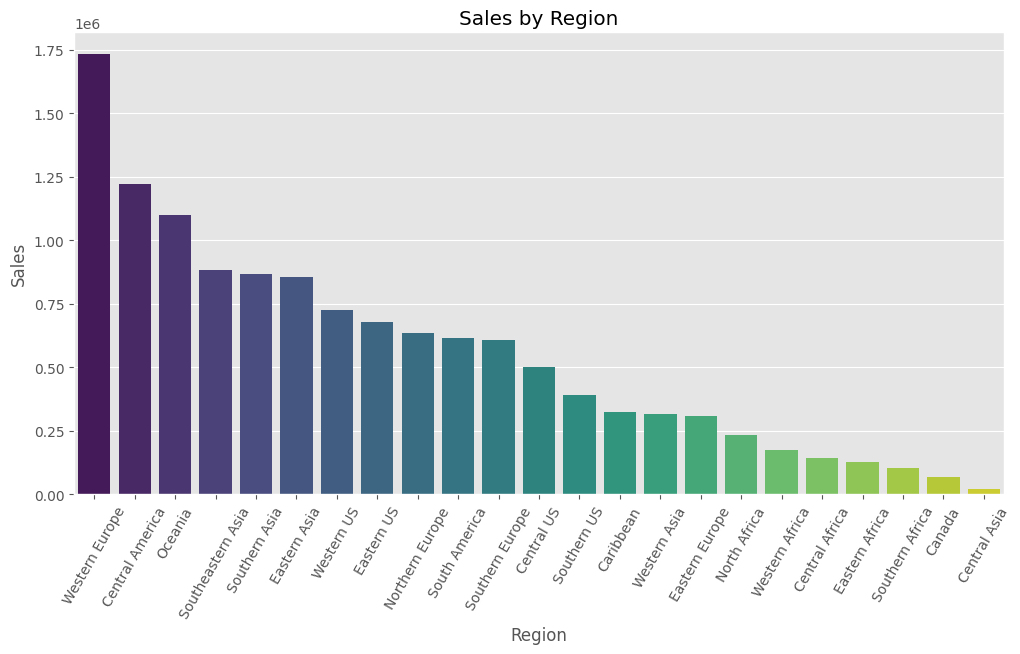

In [14]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=region.reset_index(),
    x="Region",
    y="Sales",
    palette="viridis"
)

plt.xticks(rotation=60)

plt.title("Sales by Region")

plt.show()

## 7. Customer Segment Analysis

Analyze customer segments to determine which groups contribute the most to revenue and profitability.

In [15]:
segment = (
    df.groupby("Segment")[["Sales","Profit"]]
    .sum()
)

segment

,Sales,Profit
Segment,,
Consumer,6.507949e+06,749239.78206
Corporate,3.824698e+06,441208.32866
Home Office,2.309855e+06,277009.18056


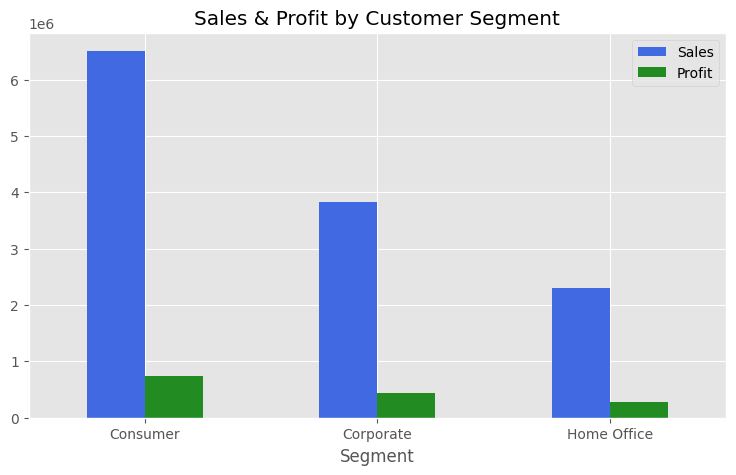

In [16]:
segment.plot(
    kind="bar",
    figsize=(9,5),
    color=["royalblue","forestgreen"]
)

plt.title("Sales & Profit by Customer Segment")

plt.xticks(rotation=0)

plt.show()

## 8. Discount vs Profit

Investigate the relationship between discounts and profitability to understand how pricing strategies influence business performance.## 8. Discount vs Profit

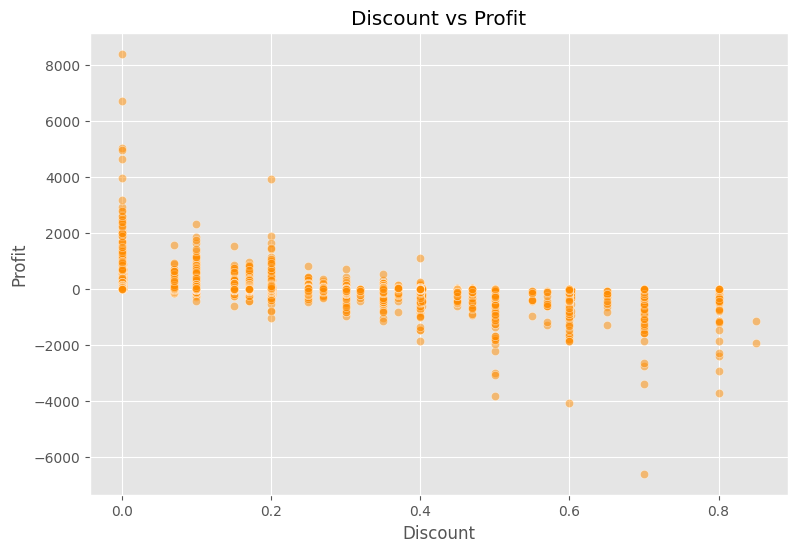

In [17]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.5,
    color="darkorange"
)

plt.title("Discount vs Profit")

plt.show()

### Observations

- Higher discounts generally reduce profitability.
- Several loss-making orders received high discounts.

## 9. Correlation Analysis

Evaluate the relationships among numerical business variables to identify patterns that may support future predictive analytics.

In [18]:
corr = df[
    [
        "Sales",
        "Profit",
        "Quantity",
        "Discount",
        "Shipping Cost",
        "Delivery Days"
    ]
].corr()

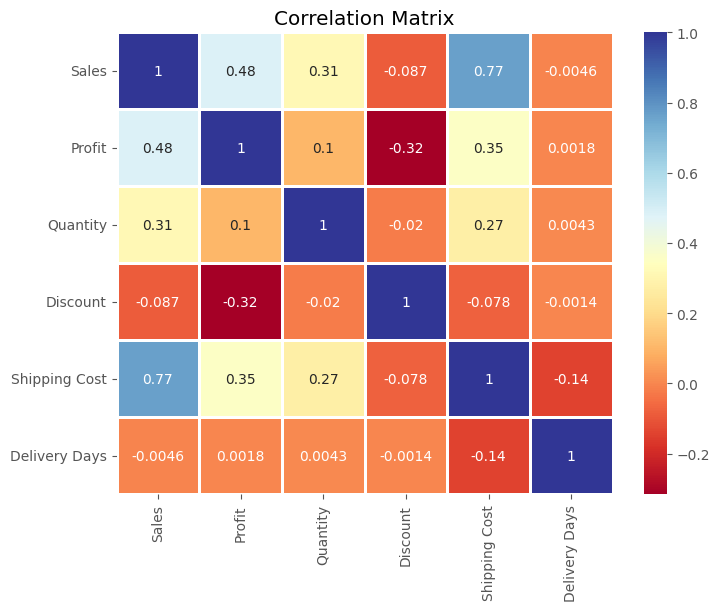

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlBu",
    linewidths=1
)

plt.title("Correlation Matrix")

plt.show()

# Key Business Insights

### Major Findings

- Sales exhibit seasonal fluctuations throughout the year.
- Technology products contribute the highest overall revenue.
- Profitability varies significantly across regions.
- Excessive discounting negatively impacts profit margins.
- Customer segments contribute differently to overall business performance.

These findings formed the basis for the interactive Power BI dashboard developed in the final stage of the project.